<a href="https://colab.research.google.com/github/kayalaVamshi/AI-Story-Video-Generator/blob/main/GenAI_Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2.Image Generation with GANs: Train a simple GAN to generate MNIST digit images.**

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


Starting GAN training...
Epoch [1/50], Step [200/469], D Loss: 1.2887, G Loss: 0.9215
Epoch [1/50], Step [400/469], D Loss: 0.7656, G Loss: 1.1660
Epoch [2/50], Step [200/469], D Loss: 0.8237, G Loss: 1.7873
Epoch [2/50], Step [400/469], D Loss: 0.9471, G Loss: 1.3717
Epoch [3/50], Step [200/469], D Loss: 1.2608, G Loss: 0.5655
Epoch [3/50], Step [400/469], D Loss: 1.3675, G Loss: 3.9236
Epoch [4/50], Step [200/469], D Loss: 0.7859, G Loss: 1.3142
Epoch [4/50], Step [400/469], D Loss: 0.8381, G Loss: 1.9629
Epoch [5/50], Step [200/469], D Loss: 0.8899, G Loss: 1.8775
Epoch [5/50], Step [400/469], D Loss: 0.7652, G Loss: 1.5276
Epoch [6/50], Step [200/469], D Loss: 0.8256, G Loss: 2.3030
Epoch [6/50], Step [400/469], D Loss: 0.8517, G Loss: 1.3964
Epoch [7/50], Step [200/469], D Loss: 0.6572, G Loss: 1.6226
Epoch [7/50], Step [400/469], D Loss: 0.7644, G Loss: 2.0504
Epoch [8/50], Step [200/469], D Loss: 1.2328, G Loss: 0.6458
Epoch [8/50], Step [400/469], D Loss: 0.7754, G Loss: 1.5057

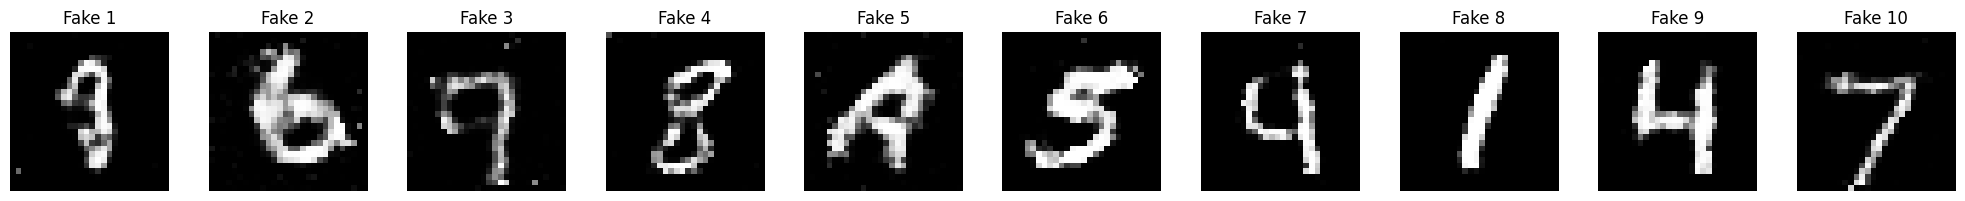

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Reproducibility for consistent losses
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size, learning_rate, num_epochs, latent_dim = 128, 0.0002, 50, 100
image_size = 28 * 28

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_loader = DataLoader(datasets.MNIST('./data', True, transform, download=True), batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size), nn.Tanh())
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid())
    def forward(self, img): return self.model(img.view(img.size(0), -1))

G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(0.5, 0.999))

print("Starting GAN training...")
for epoch in range(num_epochs):
    for step, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # Train Discriminator
        z = torch.randn(bs, latent_dim).to(device)
        fake = G(z)
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)
        d_loss = criterion(D(real_imgs), real_labels) + criterion(D(fake.detach()), fake_labels)
        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # Train Generator
        g_loss = criterion(D(G(torch.randn(bs, latent_dim).to(device))), real_labels)
        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # Progress print exactly as in lab manual (at step 200)
        if (step + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{step+1}/{len(train_loader)}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")
print("Training completed!")

# === SHOW SAMPLE GENERATED IMAGES ===
print("\nGenerating and visualizing 10 sample MNIST digits from the trained GAN...")
G.eval()
with torch.no_grad():
    z = torch.randn(10, latent_dim).to(device)
    fake_images = G(z)

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    img = fake_images[i].view(28, 28).cpu().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Fake {i+1}")
plt.tight_layout()
plt.show()
